In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tarp import get_tarp_coverage

from msi.utils import diagnostics

In [7]:
# taken from the TARP repo here https://github.com/Ciela-Institute/tarp/blob/main/notebooks/test.ipynb

def generate_psd_matrix(n):
    # generate random array of appropriate size
    arr_size = int(n * (n - 1) / 2)
    arr = np.random.rand(arr_size)

    # convert array to symmetric matrix
    mat = np.zeros((n, n))
    triu_indices = np.triu_indices(n, k=1)
    mat[triu_indices] = arr
    mat += mat.T

    # check if matrix is positive semidefinite
    eigenvals = np.linalg.eigvalsh(mat)
    if np.all(eigenvals >= 0):
        return mat
    else:
        # if not, add identity matrix to make it PSD
        mat = mat + np.eye(n) * abs(eigenvals.min()) * 2
        return mat
    

def generate_correlated_samples(num_samples, num_sims, num_dims):
    """ Generate samples and true parameter values """
    theta = np.random.uniform(low=-5, high=5, size=(num_sims, num_dims))
    cov = [generate_psd_matrix(num_dims) for _ in range(num_sims)]
    cov = np.concatenate(cov).reshape(num_sims, num_dims, num_dims)
    samples = [np.random.multivariate_normal(mean=theta[i], cov=cov[i], size=num_samples) for i in range(num_sims)]
    samples = np.stack(samples)
    samples = samples.transpose(1, 0, 2)
    theta = [np.random.multivariate_normal(mean=theta[i], cov=cov[i], size=1) for i in range(num_sims)]
    theta = np.stack(theta)[:,0]
    return samples, theta

samples, theta = generate_correlated_samples(num_samples=1000, num_sims=800, num_dims=10)

# Tests of Accuracy with Random Points (TARP)

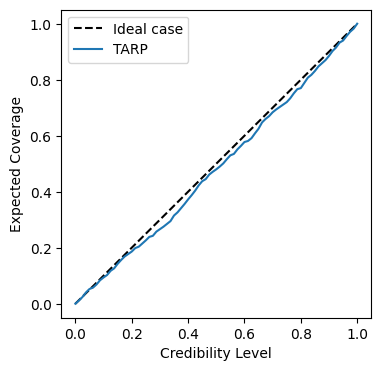

In [12]:
ecp, alpha = get_tarp_coverage(samples, theta, references='random', metric='euclidean', norm = True, seed = 5)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

plt.subplots_adjust(wspace=0.4)

# empirical expected coverage probablity (EECP)